In [11]:
from itertools import cycle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from STiMetaD import STiMetaD
import numpy as np
import pickle
from common.consts import groupByResidue, groupByProperty, mutation_map, proteins, thresholds
from common.utils import estimateMFPT

thresholds = np.arange(0.2, 0.50, 0.04)
short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

top5_evec_dot = pd.read_csv('../data/top5_evec_dot.csv', index_col='Mutant')
eigenvalue_data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
full_evec_dot = pd.read_csv('../data/full_evec_dot.csv', index_col='Mutant')
avg_change_diff = pd.read_csv('../data/average_change_difference.csv', index_col='Mutant')
avg_change_folded = pd.read_csv('../data/average_change_folded.csv', index_col='Mutant')
avg_change_unfolded = pd.read_csv('../data/average_change_unfolded.csv', index_col='Mutant')
cov_dot_product = pd.read_csv('../data/cov_dot_products.csv', index_col='Mutant')
diagonal_cov_dot_products = pd.read_csv('../data/diagonal_cov_dot_products.csv', index_col='Mutant')
variance_differences = pd.read_csv('../data/variance_differences.csv', index_col='Mutant')


def collect_df(all_mfpt, th: float, sample_size: int):
    rows = []

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.sort(np.array(all_mfpt[long_name][th]))[:sample_size]
        mfpt, lim = estimateMFPT(s, 10)
        print(f"{long_name} ({short}): {(mfpt * 1e-6):.4g} us, extra: {lim:.4g}")

        rows.append({
            "long": long_name,
            "short": short,
            "eigenvalue": eigenvalue_data.loc[short, "eigenvalue"],
            "mfpt": mfpt,
            "lim": lim,
            "full_evec_dot": full_evec_dot['full_evec_dot'].get(short, None),
            "cos_sim_folded": cov_dot_product['CosSim_Folded'].get(short, None),
            "cos_sim_unfolded": cov_dot_product['CosSim_Unfolded'].get(short, None),
            "avg_change_diff": avg_change_diff['AvgChange_Diff_F-U'].get(short, None),
            "diagonal_cov_dot_folded": diagonal_cov_dot_products['Diagonal_Dot_Folded'].get(short, None),
            "diagonal_cov_dot_unfolded": diagonal_cov_dot_products['Diagonal_Dot_Unfolded'].get(short, None),
            "abs_dvar_folded": variance_differences['abs_dvar_F'].get(short, None),
            "avg_change_folded": avg_change_folded['AvgChange_Folded'].get(short, None),
            "avg_change_unfolded": avg_change_unfolded['AvgChange_Unfolded'].get(short, None),
            "abs_dvar_unfolded": variance_differences['abs_dvar_U'].get(short, None),
            "top5_evec_dot": top5_evec_dot['top5_evec_dot'].get(short, None),
            "residue_idx": short_to_residue.get(short),
            "property_grp": short_to_property.get(short),
        })

    df = pd.DataFrame(rows)
    df.set_index("short", inplace=True)
    return df


chignolin (Wildtype): 4.653 us, extra: 12
YYCPETGTWY (D2C): 14.08 us, extra: 20
YYDPETGTWE (Y9E): 0.3875 us, extra: 19
YYRPETGTWY (D2R): 11.54 us, extra: 24
YYAPETGTWY (D2A): 3.084 us, extra: 14
YYDPETGQWY (T7Q): 24.48 us, extra: 14
YYDPETGTWG (Y9G): 0.4607 us, extra: 53
YYDPETGTWQ (Y9Q): 0.8043 us, extra: 22
YYNPETGTWY (D2N): 0.7326 us, extra: 12
YYEPETGTWY (D2E): 7.003 us, extra: 13
YYDPETGTWR (Y9R): 1.426 us, extra: 14
YYDPETGVWY (T7V): 23.95 us, extra: 26
YYDPETGYWY (T7Y): 8.172 us, extra: 26
YYDPETGTWV (Y9V): 0.2203 us, extra: 12
YYDPETGRWY (T7R): 294.8 us, extra: 34


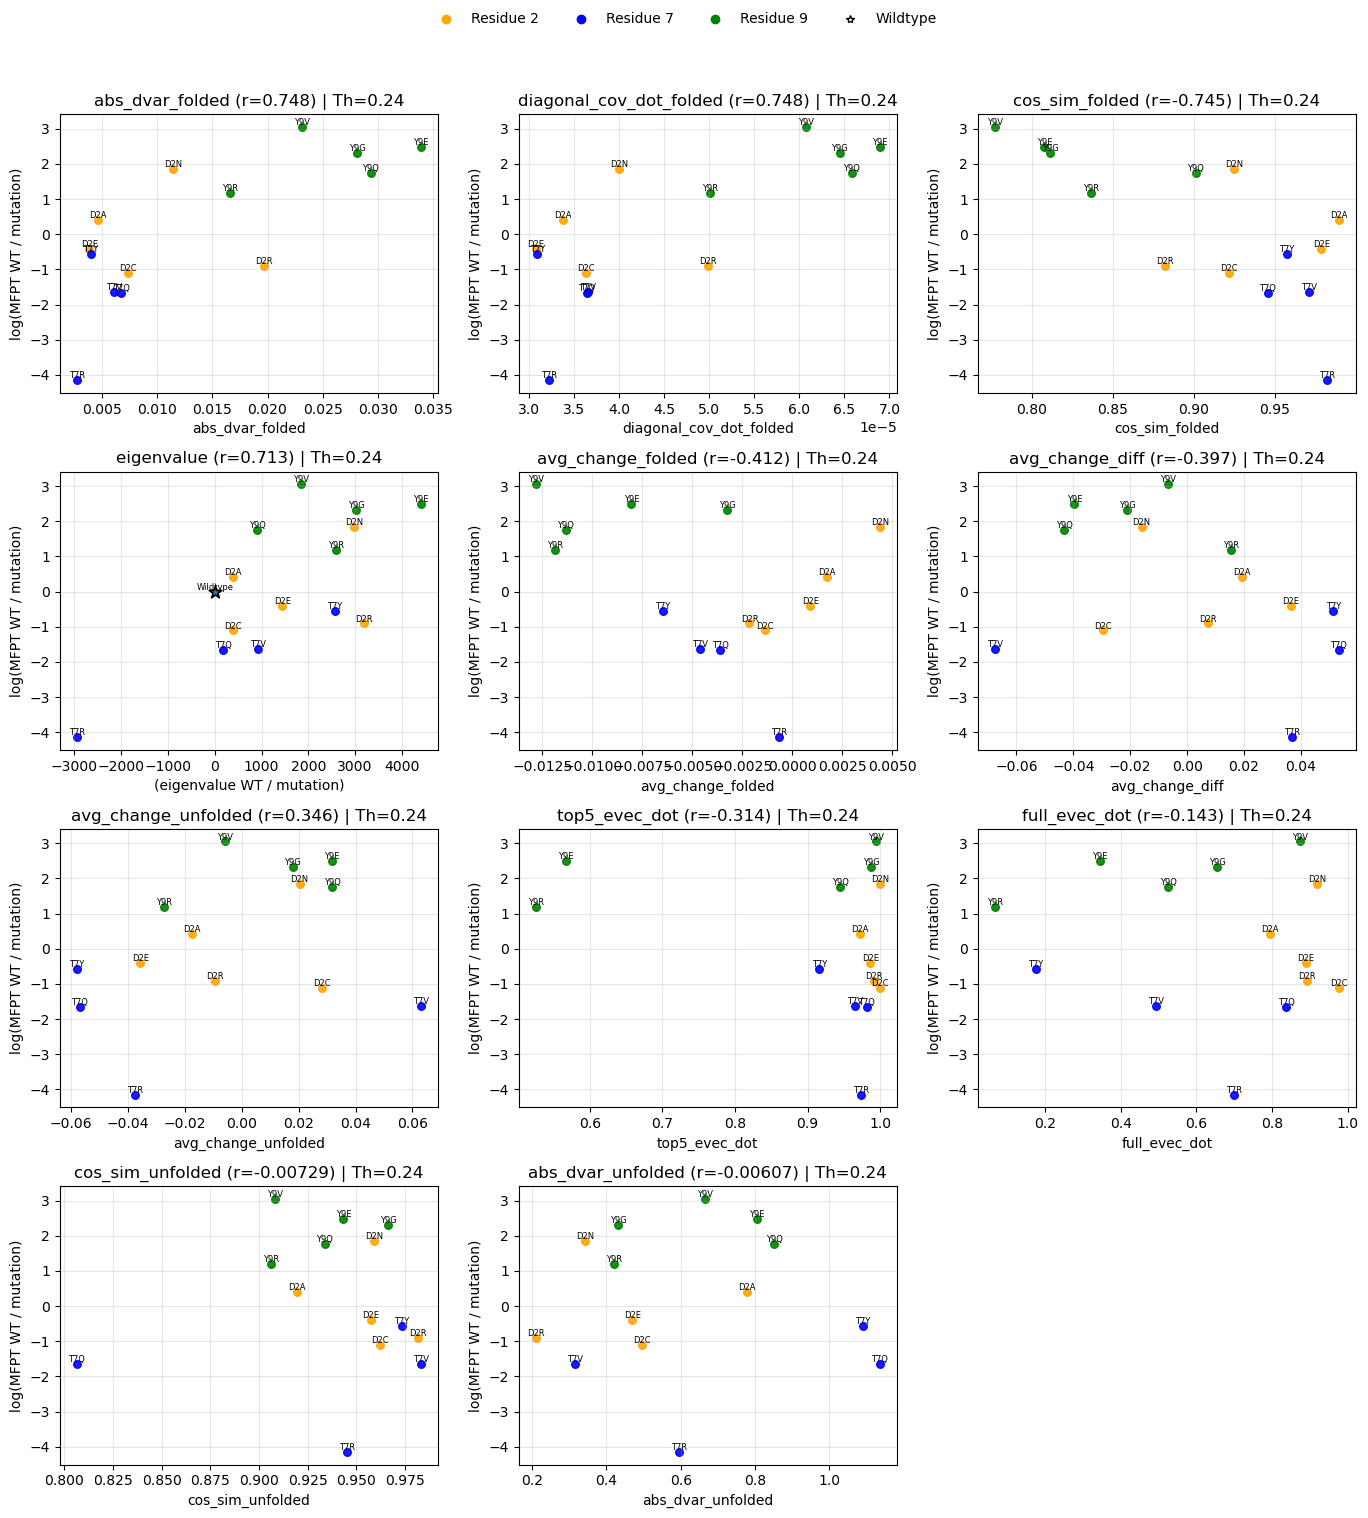

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pickle

def _ratio_or_raw(wt, arr, use_log, colname):
    if pd.isna(wt):
        return arr
    return wt - arr

def plot_mfpt_corr_grid(
    df: pd.DataFrame,
    prop_cols,
    wt_label='Wildtype',
    group_col='residue_idx',
    annotate=True,
    th=None,
    log_prop=True,
    ncols=3
):
    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())
    base_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    res_colors = {k: base_colors[i % len(base_colors)] for i, k in enumerate(res_keys)}
    res_colors[2] = 'orange'
    res_colors[7] = 'blue'
    res_colors[9] = 'green'
    pearson_spearman = {}
    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    wt_star = dict(s=90, marker='*', edgecolors='k', linewidths=1.2, zorder=3)

    for prop_col in prop_cols:
        wt_prop = df.loc[wt_label, prop_col]
        x_all = df[prop_col].to_numpy() if wt_prop == None else _ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop, prop_col)
        y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
        mask = np.isfinite(x_all) & np.isfinite(y_all)
        pearson, _ = stats.pearsonr(x_all[mask], y_all[mask]) if mask.any() else (np.nan, None)
        pearson_spearman[prop_col] = pearson

    ordered_props = sorted(prop_cols, key=lambda p: abs(pearson_spearman[p]), reverse=True)
    n = len(ordered_props)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.8 * nrows), squeeze=False)

    for idx, prop_col in enumerate(ordered_props):
        ax = axes[idx // ncols][idx % ncols]
        wt_prop = df.loc[wt_label, prop_col]
        x_all = _ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop, prop_col)
        y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
        mask = np.isfinite(x_all) & np.isfinite(y_all)
        for k in res_keys:
            sub = df[df[group_col] == k]
            if sub.empty:
                continue
            x = _ratio_or_raw(wt_prop, sub[prop_col].to_numpy(), log_prop, prop_col)
            y = np.log(wt_mfpt / sub['mfpt'].to_numpy())
            ax.scatter(x, y, s=30, alpha=0.9, c=res_colors.get(k))
        if not pd.isna(wt_prop):
            ax.scatter(0 if log_prop else wt_prop, 0, **wt_star)
        if annotate:
            names = df.index.to_numpy()
            for xv, yv, name, m in zip(x_all, y_all, names, mask):
                if m:
                    ax.text(xv, yv, name, fontsize=6, ha='center', va='bottom')
        pearson = pearson_spearman[prop_col]
        xlabel = (f'({prop_col} WT / mutation)' if log_prop and not pd.isna(wt_prop) else prop_col)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('log(MFPT WT / mutation)')
        suffix = f" | Th={th:.3g}" if th is not None else ""
        ax.set_title(f"{prop_col} (r={pearson:.3g}){suffix}")
        ax.grid(True, alpha=0.3)

    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    handles = [Line2D([0], [0], marker='o', linestyle='',
                      color=res_colors[k], label=f"Residue {k}") for k in res_keys]
    handles.append(Line2D([0], [0], marker='*', linestyle='', color='w',
                          markeredgecolor='k', label=wt_label))
    fig.legend(handles=handles, loc='upper center', ncol=min(len(handles), 6), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return pearson_spearman

props = [
    'cos_sim_unfolded', 'cos_sim_folded', 
    'eigenvalue', 'full_evec_dot', 'avg_change_diff', 'avg_change_folded',
    'avg_change_unfolded', 
    'diagonal_cov_dot_folded', 'abs_dvar_folded', 'abs_dvar_unfolded',
    'top5_evec_dot',
]

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)
sample_size = 200
th = thresholds[1]

df = collect_df(all_mfpt, th, sample_size)

stats_map = plot_mfpt_corr_grid(df, props, annotate=True, th=th, log_prop=True, ncols=3)
